<a href="https://colab.research.google.com/github/ArthiNelwadkar/EV-Data-Analysis/blob/main/Data_Visualization_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Object `count` not found.


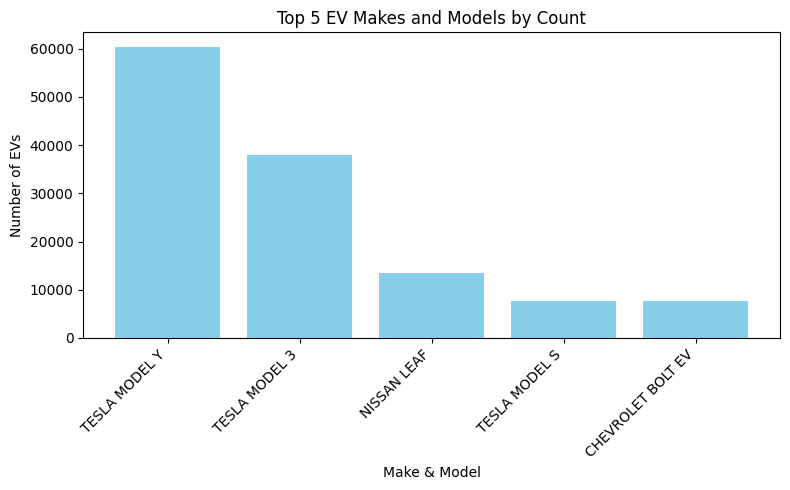

In [1]:
1: Create a bar chart showing the top 5 EV makes and models by count

import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Load dataset
df = pd.read_csv("Electric_Vehicle_Population_Data.csv")

# Step 2: Group by Make + Model and count
make_model_counts = (
    df.groupby(['Make','Model'])
      .size()
      .reset_index(name='Count')
      .sort_values(by='Count', ascending=False)
)

# Step 3: Select top 5
top5 = make_model_counts.head(5)

# Step 4: Create bar chart
plt.figure(figsize=(8,5))
plt.bar(top5['Make'] + " " + top5['Model'], top5['Count'], color='skyblue')
plt.title("Top 5 EV Makes and Models by Count")
plt.xlabel("Make & Model")
plt.ylabel("Number of EVs")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [7]:
 #2: Use a heatmap or choropleth map to visualize EV distribution by county

import pandas as pd
import folium
from folium.plugins import HeatMap

# Load dataset
df = pd.read_csv("Electric_Vehicle_Population_Data.csv")

# Step 1: Clean the Vehicle Location column
df['Vehicle Location'] = df['Vehicle Location'].astype(str).str.strip("()")

# Step 2: Split only rows with valid coordinates
split_coords = df['Vehicle Location'].str.split(",", expand=True)

# Step 3: Assign columns safely (check if both exist)
if split_coords.shape[1] >= 2:
    df['Latitude'] = pd.to_numeric(split_coords[0], errors='coerce')
    df['Longitude'] = pd.to_numeric(split_coords[1], errors='coerce')
else:
    df['Latitude'] = pd.NA
    df['Longitude'] = pd.NA

# Step 4: Drop invalid rows
df = df.dropna(subset=['Latitude','Longitude'])

# Step 5: Create heatmap
m = folium.Map(location=[47.5, -120.5], zoom_start=7)
HeatMap(data=df[['Latitude','Longitude']], radius=8, blur=6).add_to(m)

m


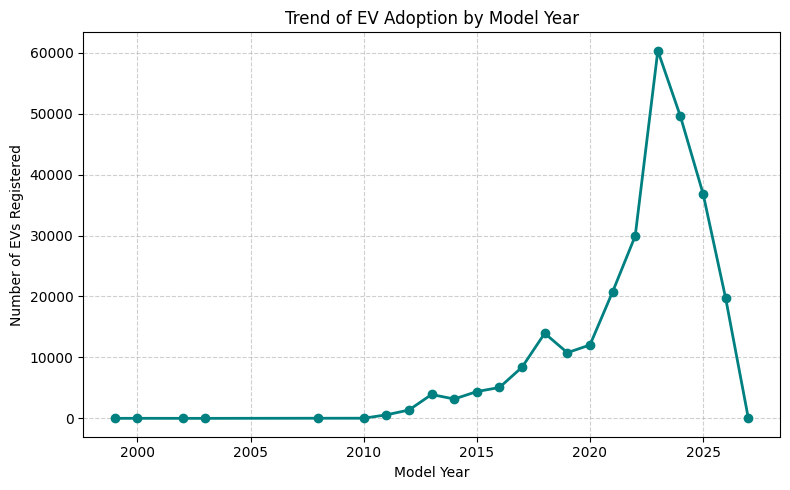

In [8]:
#3 : Create a line graph showing the trend of EV adoption by model year

import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Load dataset
df = pd.read_csv("Electric_Vehicle_Population_Data.csv")

# Step 2: Group by Model Year and count EVs
ev_trend = (
    df.groupby('Model Year')
      .size()
      .reset_index(name='EV_Count')
      .sort_values(by='Model Year')
)

# Step 3: Plot line graph
plt.figure(figsize=(8,5))
plt.plot(ev_trend['Model Year'], ev_trend['EV_Count'], marker='o', color='teal', linewidth=2)
plt.title("Trend of EV Adoption by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Number of EVs Registered")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


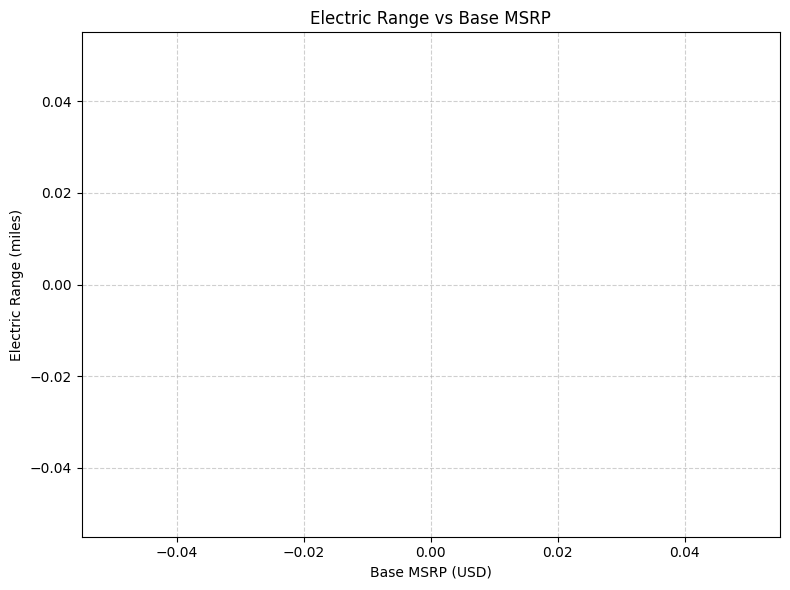

In [9]:
#4 :Generate a scatter plot comparing electric range vs. base MSRP to see pricing trends

import pandas as pd
import matplotlib.pyplot as plt

# Load EV dataset
df = pd.read_csv("Electric_Vehicle_Population_Data.csv")

# Load MSRP lookup
msrp_df = pd.read_csv("EV_MSRP_Data.csv")

# Merge on Make + Model
merged_df = pd.merge(df, msrp_df, on=['Make','Model'], how='left')

# Drop rows missing values
merged_df = merged_df.dropna(subset=['Electric Range','Base MSRP'])

# Scatter plot
plt.figure(figsize=(8,6))
plt.scatter(merged_df['Base MSRP'], merged_df['Electric Range'],
            alpha=0.6, c='teal', edgecolors='k')
plt.title("Electric Range vs Base MSRP")
plt.xlabel("Base MSRP (USD)")
plt.ylabel("Electric Range (miles)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



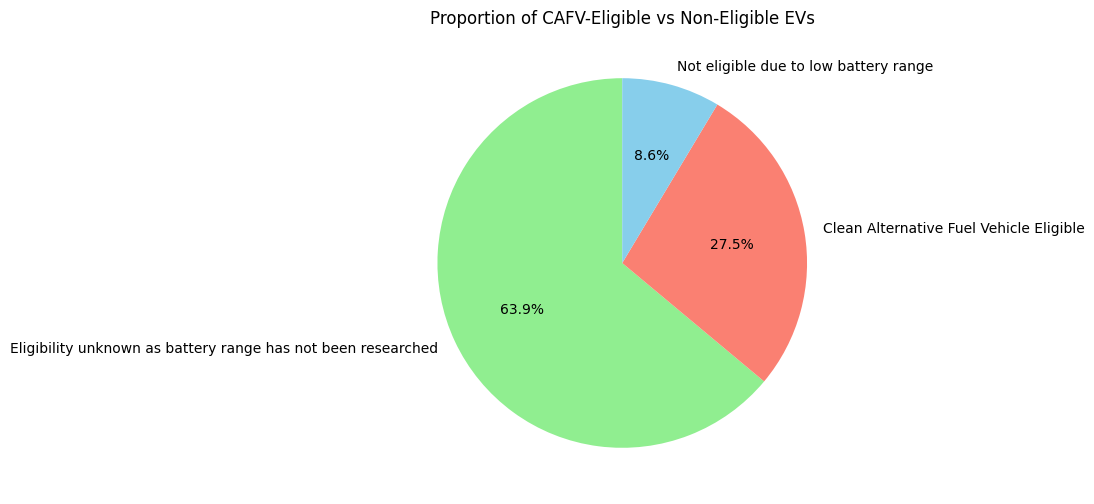

In [10]:
#5 : Plot a pie chart showing the proportion of CAFV-eligible vs. non-eligible EVs.

import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Load dataset
df = pd.read_csv("Electric_Vehicle_Population_Data.csv")

# Step 2: Count CAFV eligibility
caf_counts = df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].value_counts()

# Step 3: Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(caf_counts, labels=caf_counts.index, autopct='%1.1f%%',
        startangle=90, colors=['lightgreen','salmon','skyblue'])
plt.title("Proportion of CAFV-Eligible vs Non-Eligible EVs")
plt.show()


In [11]:
#6 : Use a geospatial map to display EV registrations based on vehicle location.

import pandas as pd
import folium

# Step 1: Load dataset
df = pd.read_csv("Electric_Vehicle_Population_Data.csv")

# Step 2: Clean Vehicle Location column
df['Vehicle Location'] = df['Vehicle Location'].astype(str).str.strip("()")

# Step 3: Split into Latitude and Longitude safely
split_coords = df['Vehicle Location'].str.split(",", expand=True)

if split_coords.shape[1] >= 2:
    df['Latitude'] = pd.to_numeric(split_coords[0], errors='coerce')
    df['Longitude'] = pd.to_numeric(split_coords[1], errors='coerce')
else:
    df['Latitude'] = pd.NA
    df['Longitude'] = pd.NA

# Step 4: Drop invalid rows
df = df.dropna(subset=['Latitude','Longitude'])

# Step 5: Create base map (centered on Washington State as example)
m = folium.Map(location=[47.5, -120.5], zoom_start=7)

# Step 6: Add markers for each EV registration
for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=3,
        color='blue',
        fill=True,
        fill_opacity=0.6
    ).add_to(m)

# Step 7: Display map
m

